#Overview
The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral). The training set consists of 28,709 examples and the public test set consists of 3,589 examples.
# Task
Train a VGG-style convolutional neural network from the ground up using the provided training dataset. The goal is to classify facial expressions into one of seven emotion categories: angry, disgust, fear, happy, sad, surprise, and neutral.
# Tham khảo
[HUMAN EMOTION DETECTION](https://www.kaggle.com/code/mohamedchahed/human-emotion-detection#%F0%9F%92%BE-Data) <br>
[VGG-like Neural Network on MNIST dataset](https://www.kaggle.com/code/shemlaya/vgg-like-neural-network-on-mnist-dataset)

In [ ]:
# 1. Import ML lib
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Dataset đã tải lên google drive gửi trên group nhóm

icml_face_data_dir = "/content/drive/MyDrive/[CDXLASVS] Final Seminar/dataset3/icml_face_data.csv"  # Directory containing the data

# 1. Data discover

In [ ]:
icml_face_data_df = pd.read_csv(icml_face_data_dir)

In [ ]:
train_df = icml_face_data_df[icml_face_data_df[" Usage"] == "Training"]
train_df.head(1)

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...


In [ ]:
val_df = icml_face_data_df[icml_face_data_df[" Usage"] == "PublicTest"]
val_df.head(1)

,emotion,Usage,pixels
28709,0,PublicTest,254 254 254 254 254 249 255 160 2 58 53 70 77 ...


In [ ]:
test_df = icml_face_data_df[icml_face_data_df[" Usage"] == "PrivateTest"]
test_df.head(1)

,emotion,Usage,pixels
32298,0,PrivateTest,170 118 101 88 88 75 78 82 66 74 68 59 63 64 6...


In [ ]:
print(f"Num of training samples: {len(train_df)}")
print(f"Num of validation samples: {len(val_df)}")
print(f"Num of test samples: {len(test_df)}")

Num of training samples: 28709
Num of validation samples: 3589
Num of test samples: 3589


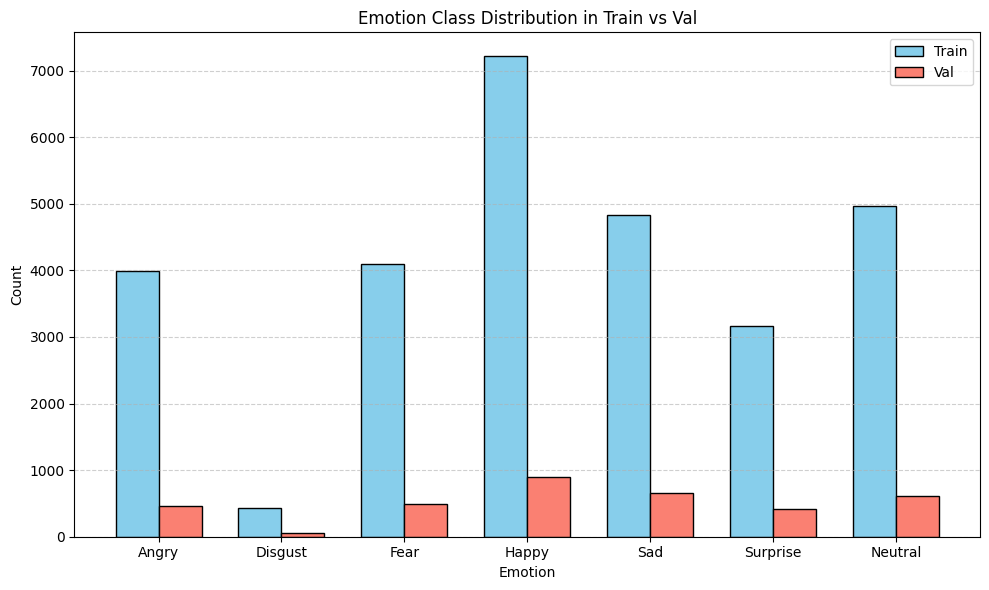

In [ ]:
# Emotion classes and label map
emotion_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
label_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Map numeric labels to emotion names for counting (without creating new column)
def get_emotion_counts(df):
    # Convert numeric emotion labels to names temporarily
    emotions_as_names = df['emotion'].map(label_map)
    # Count and reindex to maintain order
    counts = emotions_as_names.value_counts().reindex(emotion_classes)
    return counts

train_counts = get_emotion_counts(train_df)
public_test_counts = get_emotion_counts(val_df)

# Plot
x = np.arange(len(emotion_classes))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_counts.values, width, label='Train', color='skyblue', edgecolor='black')
plt.bar(x + width/2, public_test_counts.values, width, label='Val', color='salmon', edgecolor='black')

plt.xticks(x, emotion_classes)
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Emotion Class Distribution in Train vs Val')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 2.Data preprocess

## 2.1. Calculate class weight for imbalanced dataset

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4, 5, 6]),
    y=train_df['emotion']  # numeric labels
)

# Convert to dictionary if needed
class_weights = dict(zip(range(len(emotion_classes)), class_weights))

# Display result
print("Class Weights:")
for i, emotion in enumerate(emotion_classes):
    print(f"{emotion} ({i}): {class_weights[i]:.4f}")

Class Weights:
Angry (0): 1.0266
Disgust (1): 9.4066
Fear (2): 1.0010
Happy (3): 0.5684
Sad (4): 0.8491
Surprise (5): 1.2934
Neutral (6): 0.8260


## 2.2. Generate train, val, and test dataset

In [ ]:
def extract_features_labels(data):
    image_array = np.zeros(shape=(len(data), 48, 48, 1))
    image_label = np.array(list(map(int, data['emotion'])))

    for i, row in enumerate(data.index):
        image = np.fromstring(data.loc[row, ' pixels'], dtype=int, sep=' ')
        image = np.reshape(image, (48, 48, 1))
        image_array[i] = image

    return image_array, image_label

In [ ]:
# Split the feature and label
train_features, train_labels = extract_features_labels(train_df)
val_features, val_labels = extract_features_labels(val_df)
test_features, test_labels = extract_features_labels(test_df)

train_dataset = tf.data.Dataset.from_tensor_slices((train_features, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_features, val_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_features, test_labels))

In [ ]:
num_classes = 7  # number of emotion classes

def one_hot_encode_label(image, label):
    label = tf.cast(label, tf.int32)  # cast to int32 first
    label = tf.one_hot(label, depth=num_classes)
    return image, label

train_dataset = train_dataset.map(one_hot_encode_label)
val_dataset = val_dataset.map(one_hot_encode_label)
test_dataset = test_dataset.map(one_hot_encode_label)

## 2.3. Augmentation and prefect data

In [ ]:
# Rescale the pixel value to 0 to 1
normalization_layer = layers.Rescaling(1./255)

# Data augmentation (applied only to training data)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15, fill_mode='reflect'),
    layers.RandomZoom(0.15, fill_mode='reflect'),
    layers.RandomTranslation(0.1, 0.1, fill_mode='reflect'),
    layers.RandomBrightness(0.2, value_range=(0, 1)),
    layers.RandomContrast(0.2),

    # Add some noise occasionally
    layers.Lambda(lambda x: tf.cond(
        tf.random.uniform([]) < 0.3,  # 30% chance
        lambda: x + tf.random.normal(tf.shape(x), stddev=0.05),
        lambda: x
    )),
], name="data_augmentation")

batch_size = 128

# Apply normalization and augmentation
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
augmented_train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
augmented_train_dataset = augmented_train_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset = test_dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)



# 3.Train model

## 3.1. Create a folder to store related data

In [ ]:
base_dir = "/content/drive/MyDrive/[CDXLASVS] Final Seminar/pretrain_model"
os.makedirs(base_dir, exist_ok=True)

run_id = 1
while os.path.exists(f"{base_dir}/train{run_id}"):
    run_id += 1
run_dir = f"{base_dir}/train{run_id}"
os.makedirs(run_dir)


## 3.2. Define a model

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

        # Block 1: 1 Conv layers, 32 filters
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # Block 2: 1 Conv layers, 64 filters
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # Block 3: 3 Conv layers, 128 filters
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.4),

        # Block 4: 3 Conv layers, 256 filters
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.4),

        # Dense layers
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 24, 24, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             

 Total params: 4,173,895 (15.92 MB)

 Trainable params: 4,170,887 (15.91 MB)

 Non-trainable params: 3,008 (11.75 KB)

## 3.3. Define optimizer, loss fn, and related utils

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')],
)

In [ ]:
# === Callbacks ===
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Save the best model by validation accuracy
best_model_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(run_dir, 'best_model.keras'),
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Save the last model at the end of every epoch
last_model_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(run_dir, 'last_model.keras'),
    save_best_only=False,
    verbose=1
)

# Combine all callbacks into a single list
callbacks = [early_stop_cb, reduce_lr_cb, best_model_cb, last_model_cb]

## 3.4. Start the training

In [ ]:
history = model.fit(
    augmented_train_dataset,  # Use augmented dataset for training
    validation_data=val_dataset,
    epochs=200,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/200
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1522 - loss: 3.0799
Epoch 1: val_accuracy improved from -inf to 0.16941, saving model to /content/drive/MyDrive/[CDXLASVS] Final Seminar/pretrain_model/train1/best_model.keras

Epoch 1: saving model to /content/drive/MyDrive/[CDXLASVS] Final Seminar/pretrain_model/train1/last_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.1522 - loss: 3.0793 - val_accuracy: 0.1694 - val_loss: 2.4433 - learning_rate: 0.0010
Epoch 2/200
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1613 - loss: 2.2728
Epoch 2: val_accuracy improved from 0.16941 to 0.22123, saving model to /content/drive/MyDrive/[CDXLASVS] Final Seminar/pretrain_model/train1/best_model.keras

Epoch 2: saving model to /content/drive/MyDrive/[CDXLASVS] Final Seminar/pretrain_model/train1/last_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.1613 - loss: 2.2723 - val_accuracy: 0.2212 - val_loss: 1.9834 - learning_rate: 0.00

## 3.5. Evaluate the model

In [ ]:
model.evaluate(
    test_dataset,
    verbose=1,
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5774 - loss: 1.2790


[1.2709932327270508, 0.5781554579734802]

# 4. Plot the process

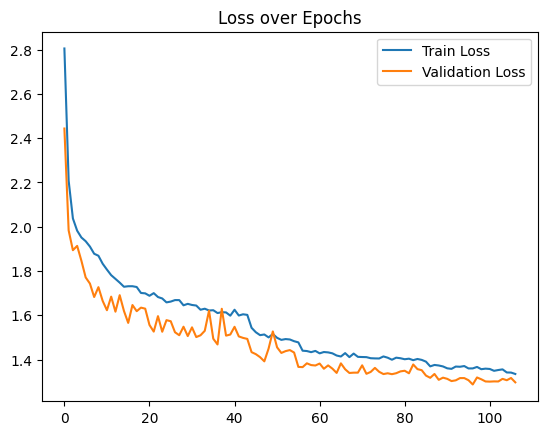

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.savefig(os.path.join(run_dir, "Loss_over_Epochs.png"))
plt.show()

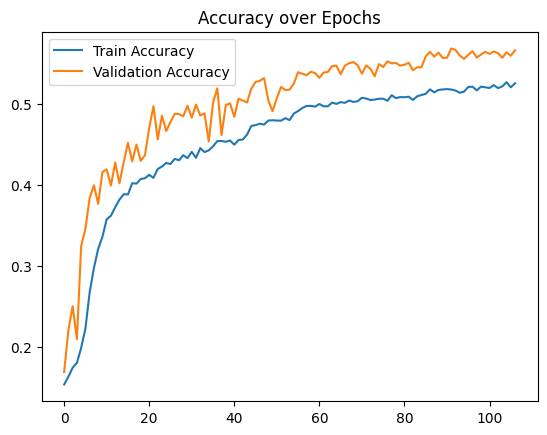

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.savefig(os.path.join(run_dir, "Accuracy_over_Epochs.png"))
plt.show()

Length y_true: 3589
Length y_pred: 3589


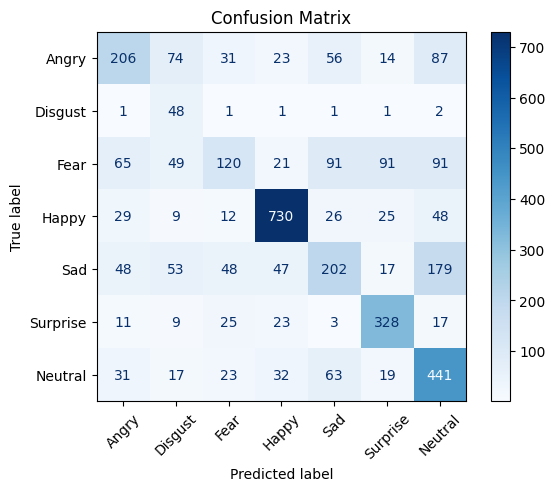

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))        # Convert one-hot to class index
    y_pred.extend(np.argmax(preds, axis=1))                 # Predicted class

# Sanity check
print("Length y_true:", len(y_true))
print("Length y_pred:", len(y_pred))

# Confusion matrix
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.savefig(os.path.join(run_dir, "Confusion_Matrix.png"))
plt.show()
